## Library

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
from unidecode import unidecode
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.geometry import Point
import plotly.express as px

## Data

In [5]:
df_cities_ra_matches = pd.read_csv("df_cities_ra_matched.csv", sep=";")
df_cities_ra_matches = df_cities_ra_matches[~df_cities_ra_matches["geometry"].isna()]

# corrgier les géometrie :
def safe_to_point(geom):
    if isinstance(geom, Point):
        return geom
    try:
        # Retirer "POINT" puis les parenthèses et espaces
        coords = geom.replace("POINT", "").replace("(", "").replace(")", "").split()
        return Point(float(coords[0]), float(coords[1]))
    except:
        return None

# Appliquer uniquement aux lignes où geometry est une string
#df_cities_ra_matches['geometry']
df_cities_ra_matches["geometry"] = df_cities_ra_matches['geometry'].apply(safe_to_point)

# lat long
df_cities_ra_matches["lon"] = df_cities_ra_matches["geometry"].apply(lambda p: p.x if p else None)
df_cities_ra_matches["lat"] = df_cities_ra_matches["geometry"].apply(lambda p: p.y if p else None)

gdf_ra = gpd.GeoDataFrame(df_cities_ra_matches, geometry='geometry', crs="EPSG:4326")

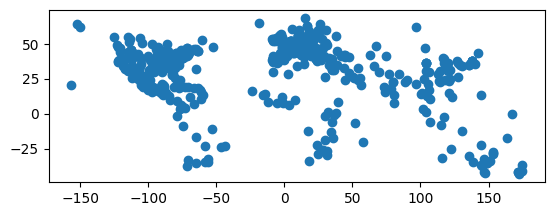

In [6]:
gdf_ra.plot()
plt.show()

In [7]:
gdf_ra.sample(3)

,venue_area_id,venue_area_clean,country_name_clean,unit_name_clean,fuzzy_score,correspondance,geometry,is_strict,status,lon,lat
549,482,haiti,haiti,haiti,100.0,Ci2Cn,POINT (-72.69087 18.93837),True,single_strict_match_awa_fuzzy,-72.690874,18.938371
457,314,jacksonville,unitedstatesofamerica,jacksonville,100.0,Ci2Ci,POINT (-77.43056 34.75432),True,single_strict_match_awa_fuzzy,-77.430556,34.754324
13,46,seattle,unitedstatesofamerica,seattle,100.0,Ci2Ci,POINT (-122.31532 47.60042),True,single_strict_match,-122.315322,47.600423


In [ ]:
from tensorflow import keras
model = keras.models.load_model("NexLoc_simple_100_final.keras")
df = pd.read_csv("city_idx_simple.csv", sep=";").merge(
    gdf_ra[["venue_area_id", "unit_name_clean", "lon", "lat"]], on="venue_area_id", how="left"
)


## Dashboard

In [10]:
import numpy as np
import pandas as pd
from dash import Dash, html, dcc, Input, Output, State
import dash
import plotly.express as px
from tensorflow.keras.preprocessing.sequence import pad_sequences
import plotly.graph_objects as go
import dash_bootstrap_components as dbc
from plotly.colors import sample_colorscale

# Mapping direct depuis le dataframe
name_to_id = dict(zip(df["unit_name_clean"], df["city_idx"]))

# couleurs cividis global
cividis_min = sample_colorscale("cividis", [0])[0]
cividis_mid = sample_colorscale("cividis", [0.5])[0]
cividis_max = sample_colorscale("cividis", [1])[0]

app = Dash(
    __name__,
    external_stylesheets=[dbc.themes.LUX],  
    requests_pathname_prefix="/user/mboualami/proxy/8050/",
    routes_pathname_prefix="/"
)

# CERULEAN, COSMO, CYBORG, DARKLY, FLATLY, JOURNAL, LITERA, LUMEN, LUX, MATERIA, MINTY, 
# MORPH, PULSE, QUARTZ, SANDSTONE, SIMPLEX, SKETCHY, SLATE, SOLAR, SPACELAB, SUPERHERO, UNITED, VAPOR, YETI, ZEPHYR.

app.layout = dbc.Container(

    fluid=True,

    children=[

        # Titre principal
        dbc.Row(
            dbc.Col(
                html.H1(
                    "Your next encore: One city more",
                    className="text-center my-4",
                    style={"color": cividis_min} 
                ),
                width=12
            )
        ),

        # Ligne principale : Graphique gauche / Contrôles droite
        dbc.Row(

            className="g-4",  # espace horizontal entre colonnes

            children=[

                # Colonne gauche : carte
                dbc.Col(
                    dbc.Card(
                        dbc.CardBody(
                            dcc.Graph(
                                id="heatmap-graph",
                                style={"height": "75vh"}
                            )
                        )
                    ),
                    md=8  # largeur 8/12
                ),

                # Colonne droite : contrôles
                dbc.Col(
                    dbc.Card(
                        dbc.CardBody([

                            #html.H4("Input your touring history", className="mb-3"),

                            dcc.Dropdown(
                                id="city-dropdown",
                                options=[
                                    {"label": name, "value": name}
                                    for name in df["unit_name_clean"].drop_duplicates()
                                ],
                                placeholder="Select a location",
                                className="mb-3"
                            ),

                            dbc.Button(
                                "Add to touring history",
                                id="add-button",
                                className="me-2 mb-3",
                                style={
                                    "backgroundColor": cividis_min,
                                    "border": "none",
                                    "color": "white"
                                }
                            ),

                            dbc.Button(
                                "Reset",
                                id="reset-button",
                                className="mb-3",
                                style={
                                    "color": cividis_min,
                                    "backgroundColor":"white",
                                    "border":"none"
                                }
                            ),

                            html.H5("Touring history", className="mt-4", style={"color": cividis_min}),

                            html.Div(
                                id="sequence-names-display",
                                className="mt-2"
                            ),

                            html.H5("Recommendations", className="mt-4", style={"color": cividis_min}), #mod
                            html.Div(id="top3-display"), #mod

                            dcc.Store(id="sequence-store")

                        ])
                    ),
                    md=4  # largeur 4/12
                )
            ]
        )
    ]
)


@app.callback(
    Output("sequence-names-display", "children"),
    Output("sequence-store", "data"),
    Input("add-button", "n_clicks"),
    Input("reset-button", "n_clicks"),
    State("city-dropdown", "value"),
    State("sequence-store", "data"),
    State("sequence-names-display", "children")
)
def update_sequence(add_clicks, reset_clicks, selected_unit, current_idx_sequence, current_name_sequence):

    ctx = dash.callback_context

    if not ctx.triggered:
        return "", []

    button_id = ctx.triggered[0]["prop_id"].split(".")[0]

    if button_id == "reset-button":
        return "", []

    current_idx_sequence = current_idx_sequence or []
    current_name_sequence = current_name_sequence or []

    if isinstance(current_name_sequence, str) and current_name_sequence != "":
        current_name_sequence = current_name_sequence.split(" → ")

    if selected_unit is None:
        return " → ".join(current_name_sequence), current_idx_sequence

    current_idx_sequence.append(name_to_id[selected_unit])
    current_name_sequence.append(selected_unit)

    return " → ".join(current_name_sequence), current_idx_sequence

@app.callback(
    Output("heatmap-graph", "figure"),
    Output("top3-display", "children"), #mod
    Input("sequence-store", "data")
)

def update_heatmap(idx_sequence):

    if not idx_sequence or len(idx_sequence) == 0:
        df_empty = pd.DataFrame({
            "lat": [0],
            "lon": [0],
            "probability": [1]
        })
        
        fig =  px.density_map(
            df_empty,
            lat="lat",
            lon="lon",
            z="probability",
            radius=1,  # minuscule pour ne pas créer de blob visible
            center=dict(lat=20, lon=0),
            zoom=0.9,
            map_style="carto-positron-nolabels"
        )

        fig.update_traces(opacity=1.0, hoverinfo="skip", hovertemplate=None, showlegend=False)
        fig.update_layout(coloraxis_showscale=False, title=None, margin=dict(l=0, r=0, t=0, b=10))
        
        return fig, " " #renvoyer figure et top3

    sequence = pad_sequences(
        [idx_sequence],
        maxlen=30,
        padding="post"
    )

    y_pred = model.predict(sequence, batch_size=1, verbose=0)
    y_pred_proba = y_pred[0]

    df_heatmap = (
        pd.DataFrame({
            "city_idx": np.arange(y_pred_proba.shape[0]),
            "probability": y_pred_proba
        })
        .merge(df, on="city_idx", how="right")
        .fillna({"probability": 0.0})
    )

    df_top3 = (
        df_heatmap
        .sort_values("probability", ascending=False)
        .head(3) 
    )

    # figure 

    fig = px.density_map(
    df_heatmap,
    lat="lat",
    lon="lon",
    z="probability",
    hover_data={"unit_name_clean": True},
    center=dict(lat=20, lon=0),
    radius=14,
    zoom=0.9,
    map_style="carto-positron-nolabels",
    color_continuous_scale="cividis"
    )
    
    fig.update_traces(
        hovertemplate="%{customdata[0]}: %{z:.2%}<extra></extra>"
    )
    
    fig.update_layout(
        title=None,
        margin=dict(l=0, r=0, t=0, b=10),
        coloraxis_colorbar=dict(
            orientation="h",
            xanchor="center",
            yanchor="bottom",
            y=0,
            title=dict(text="Next location probability", side="bottom"),
            thickness=12,
            len=0.6
        )
    )

    # top 3 display
    top3_components = []
    
    z_min = df_heatmap["probability"].min()
    z_max = df_heatmap["probability"].max()
    
    for rank, (_, row) in enumerate(df_top3.iterrows(), start=1):
    
        prob = row["probability"]
        prob_percent = prob * 100
    
        norm_value = (prob - z_min) / (z_max - z_min + 1e-12)
        bar_color = sample_colorscale("cividis", [norm_value])[0]
    
        top3_components.append(
            html.Div([
    
                html.Div(
                    f"{row['unit_name_clean']}",
                    className="fw-semibold"
                ),
    
                dbc.Progress(
                    value=prob_percent,
                    max=100,
                    label=f"{prob_percent:.1f}%",
                    className="mt-2 mb-3",
                    style={"height": "18px"},
                    color=bar_color
                )
    
            ])
        )
    
    top3_display = top3_components
    
    return fig, top3_display


app.run(
    host="0.0.0.0",
    port=8050,
    debug=False,
    use_reloader=False
)
